## Project Name: - DeepFER: Facial Emotion Recognition Using Deep Learning
### Project Type: - Deep Learning for Computer Vision
### Contribution: - Individual - Archit Dhodi

[DeepFER – Facial Emotion Recognition using Deep Learning](https://github.com/ArchitDhodi/DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning-and-Computer-Vision)

## Problem Statement: -
DeepFER: Facial Emotion Recognition Using Deep Learning aims to develop a robust and efficient system for recognizing emotions from facial expressions using advanced deep learning techniques. This project leverages Convolutional Neural Networks (CNNs) and Transfer Learning to accurately classify emotions such as happiness, sadness, anger, surprise, and more from images of human faces. The system will be trained on a diverse dataset of facial images, employing data augmentation and fine-tuning methods to enhance its performance. By integrating state-of-the-art computer vision algorithms and neural network architectures, DeepFER seeks to achieve high accuracy and real-time processing capabilities. The ultimate goal is to create a versatile tool that can be applied in various fields, including human-computer interaction, mental health monitoring, and customer service, enhancing the way machines understand and respond to human emotions.

### Dataset Overview: -

#### Dataset Composition: -
Contains images categorized into seven distinct emotion classes: angry, sad, happy, fear, neutral, disgust, and surprise.

#### Emotion Classes: -

Angry: Images depicting expressions of anger.

Sad: Images depicting expressions of sadness.

Happy: Images depicting expressions of happiness.

Fear: Images depicting expressions of fear.

Neutral: Images depicting neutral, non-expressive faces.

Disgust: Images depicting expressions of disgust.

Surprise: Images depicting expressions of surprise.

#### Image Characteristics:

High-quality facial images with diverse backgrounds and lighting conditions.

Includes both posed and spontaneous expressions to ensure robustness.

#### Data Augmentation: -

Techniques such as rotation, scaling, and flipping applied to increase dataset variability and enhance model generalization.

#### Dataset Annotations: -

Each image is labeled with its corresponding emotion class.

#### Data Source: -

Collected from publicly available facial expression databases and crowd-sourced contributions.

## Import Libraries

In [ ]:
# Import required libraries
import os
import math
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint,
    TensorBoard, CSVLogger
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_recall_fscore_support
)
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as eff_preprocess

In [2]:
# Setting mixed precision training for faster computations
mixed_precision.set_global_policy('mixed_float16')
policy = mixed_precision.global_policy()
print(f' Mixed Precision Policy: {policy.name}')
print(f' Compute dtype: {policy.compute_dtype}')
print(f' Variable dtype: {policy.variable_dtype}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU Available: {gpus}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('No GPU found. Running on CPU.')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3080 Ti, compute capability 8.6
 Mixed Precision Policy: mixed_float16
 Compute dtype: float16
 Variable dtype: float32
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration


In [ ]:
BASE_DIR = Path('images')
TRAIN_DIR = BASE_DIR / 'train'
VAL_DIR = BASE_DIR / 'validation'

CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = len(CLASS_NAMES)

# Enhanced CNN settings
IMG_HEIGHT = 48
IMG_WIDTH = 48
IMG_CHANNELS = 3
CNN_BATCH_SIZE = 128
CNN_LEARNING_RATE = 1e-4

# Transfer learning settings
TRANSFER_IMAGE_SIZE = (224, 224)
TRANSFER_BATCH_SIZE = 64
TRANSFER_LEARNING_RATE = 1e-4

EPOCHS = 150
EARLY_STOPPING_PATIENCE = 11
REDUCE_LR_PATIENCE = 4
REDUCE_LR_FACTOR = 0.25
MIN_LR = 1e-7

MODEL_DIR = Path('models')
LOG_DIR = Path('logs')
MODEL_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)

class_weights = {
    0: 1.5,
    1: 5.0,
    2: 1.5,
    3: 0.8,
    4: 1.2,
    5: 1.2,
    6: 1.8
}
CLASS_WEIGHT_VECTOR = tf.constant([class_weights[idx] for idx in range(NUM_CLASSES)], dtype=tf.float32)

print('Configuration ready:')
print(f'  Train dir: {TRAIN_DIR}')
print(f'  Val dir:   {VAL_DIR}')
print(f'  Classes:   {CLASS_NAMES}')
print(f'  CNN batch size: {CNN_BATCH_SIZE}')
print(f'  Transfer batch size: {TRANSFER_BATCH_SIZE}')

Configuration ready:
  Train dir: data\images\images\train
  Val dir:   data\images\images\validation
  Classes:   ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  CNN batch size: 128
  Transfer batch size: 64


## Dataset Analysis


In [ ]:
# Basic analysis of the dataset along with basic information for the same
def count_images(directory):
    counts = {}
    for emotion in CLASS_NAMES:
        emotion_dir = directory / emotion
        if emotion_dir.exists():
            counts[emotion] = len([f for f in emotion_dir.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
        else:
            counts[emotion] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)

def print_counts(name, counts):
    print(f'{name} distribution:')
    total = 0
    for emotion in CLASS_NAMES:
        cnt = counts.get(emotion, 0)
        print(f'  {emotion:>8}: {cnt}')
        total += cnt
    print(f'Total {name.lower()} images: {total}')
    return total

train_image_count = print_counts('Training', train_counts)
val_image_count = print_counts('Validation', val_counts)

CNN_STEP_SIZE_TRAIN = math.ceil(train_image_count / CNN_BATCH_SIZE)
CNN_STEP_SIZE_VALID = math.ceil(val_image_count / CNN_BATCH_SIZE)
TRANSFER_STEP_SIZE_TRAIN = math.ceil(train_image_count / TRANSFER_BATCH_SIZE)
TRANSFER_STEP_SIZE_VALID = math.ceil(val_image_count / TRANSFER_BATCH_SIZE)

print(f'CNN steps per epoch (train/val): {CNN_STEP_SIZE_TRAIN} / {CNN_STEP_SIZE_VALID}')
print(f'Transfer steps per epoch (train/val): {TRANSFER_STEP_SIZE_TRAIN} / {TRANSFER_STEP_SIZE_VALID}')

Training distribution:
     angry: 3993
   disgust: 436
      fear: 4103
     happy: 7164
   neutral: 4982
       sad: 4938
  surprise: 3205
Total training images: 28821
Validation distribution:
     angry: 960
   disgust: 111
      fear: 1018
     happy: 1825
   neutral: 1216
       sad: 1139
  surprise: 797
Total validation images: 7066
CNN steps per epoch (train/val): 226 / 56
Transfer steps per epoch (train/val): 451 / 111


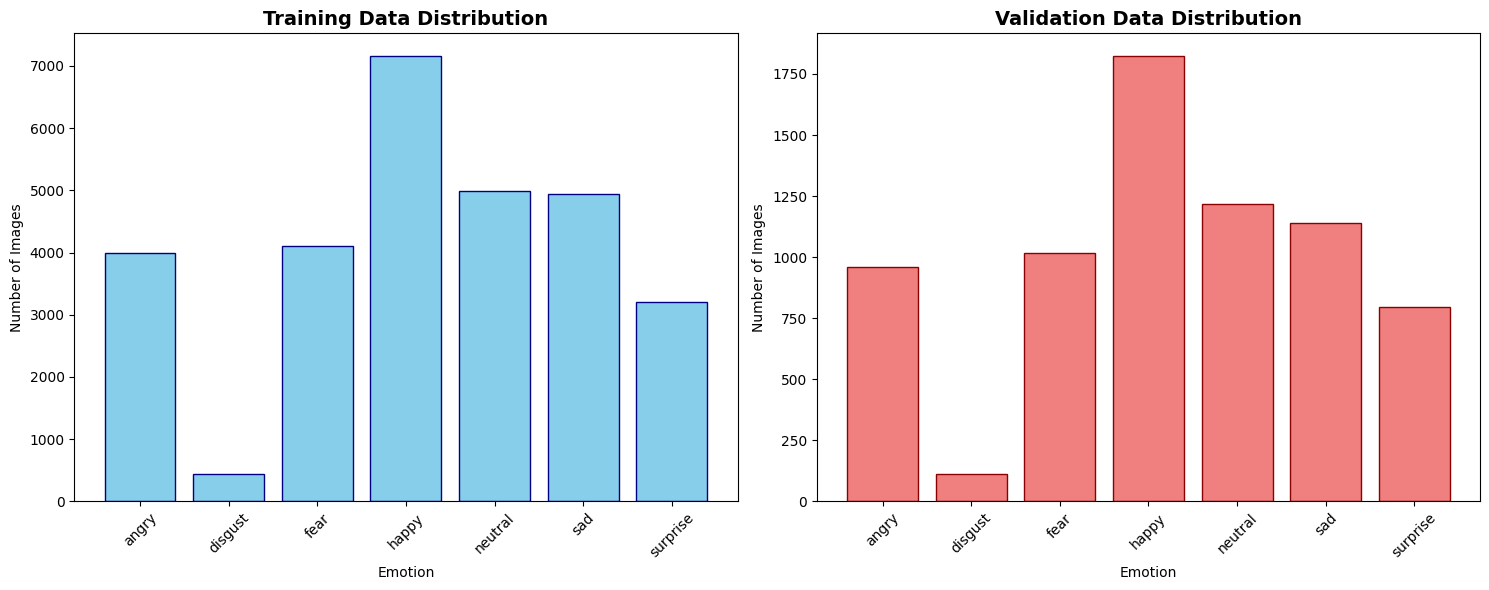

In [5]:
# Visualize distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Training distribution
ax1.bar(train_counts.keys(), train_counts.values(), color='skyblue', edgecolor='navy')
ax1.set_title('Training Data Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Emotion')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=45)
# Validation distribution
ax2.bar(val_counts.keys(), val_counts.values(), color='lightcoral', edgecolor='darkred')
ax2.set_title('Validation Data Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Emotion')
ax2.set_ylabel('Number of Images')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## ImageDataGenerator Pipeline - CNN (48x48)

In [ ]:
# Building data feeding generator for enhanced CNN
print('Building ImageDataGenerator pipelines for Enhanced CNN')

color_mode = 'rgb' if IMG_CHANNELS == 3 else 'grayscale'
target_size = (IMG_HEIGHT, IMG_WIDTH)

cnn_train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

cnn_val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

cnn_train_generator = cnn_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=CNN_BATCH_SIZE,
    shuffle=True
)

cnn_val_generator = cnn_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=target_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=CNN_BATCH_SIZE,
    shuffle=False
)

CNN_STEP_SIZE_TRAIN = math.ceil(cnn_train_generator.samples / CNN_BATCH_SIZE)
CNN_STEP_SIZE_VALID = math.ceil(cnn_val_generator.samples / CNN_BATCH_SIZE)

cnn_val_true_labels = cnn_val_generator.classes
print(f"ImageDataGenerator ready: {cnn_train_generator.samples} training images, {cnn_val_generator.samples} validation images")

Building ImageDataGenerator pipelines for Enhanced CNN...
Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
ImageDataGenerator ready: 28821 training images, 7066 validation images


In [7]:
# tf.data autotune helper
AUTOTUNE = tf.data.AUTOTUNE

## Transfer Learning Models  (224x224)


In [ ]:
# Data feeding and functions for initiating ResNet and EfficientNet
AUTOTUNE = tf.data.AUTOTUNE
print('Building transfer learning datasets')
transfer_base_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    image_size=TRANSFER_IMAGE_SIZE,
    batch_size=TRANSFER_BATCH_SIZE,
    shuffle=True,
    seed=42,
    color_mode='rgb'
)
print('Transfer class order:', transfer_base_train_ds.class_names)
assert transfer_base_train_ds.class_names == CLASS_NAMES, 'Class ordering mismatch for transfer dataset'

transfer_base_val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    image_size=TRANSFER_IMAGE_SIZE,
    batch_size=TRANSFER_BATCH_SIZE,
    shuffle=False,
    color_mode='rgb'
)

transfer_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.0417),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomZoom(0.15),
], name='transfer_augmentation')

def prepare_transfer_train_resnet(images, labels):
    images = tf.cast(images, tf.float32)
    images = transfer_augmentation(images, training=True)
    images = resnet_preprocess(images)
    labels = tf.cast(labels, tf.float32)
    sample_weights = tf.gather(CLASS_WEIGHT_VECTOR, tf.argmax(labels, axis=-1))
    return images, labels, sample_weights

def prepare_transfer_train_efficientnet(images, labels):
    images = tf.cast(images, tf.float32)
    images = transfer_augmentation(images, training=True)
    images = eff_preprocess(images)
    labels = tf.cast(labels, tf.float32)
    sample_weights = tf.gather(CLASS_WEIGHT_VECTOR, tf.argmax(labels, axis=-1))
    return images, labels, sample_weights

def prepare_transfer_val_resnet(images, labels):
    images = resnet_preprocess(tf.cast(images, tf.float32))
    labels = tf.cast(labels, tf.float32)
    return images, labels


def prepare_transfer_val_efficientnet(images, labels):
    images = eff_preprocess(tf.cast(images, tf.float32))
    labels = tf.cast(labels, tf.float32)
    return images, labels

train_ds_resnet = transfer_base_train_ds.map(prepare_transfer_train_resnet, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
train_ds_eff = transfer_base_train_ds.map(prepare_transfer_train_efficientnet, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

val_ds_resnet = transfer_base_val_ds.map(prepare_transfer_val_resnet, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_eff = transfer_base_val_ds.map(prepare_transfer_val_efficientnet, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Transfer train element spec (ResNet):', train_ds_resnet.element_spec)
print('Transfer val element spec (ResNet):', val_ds_resnet.element_spec)

Building transfer learning datasets...
Found 28821 files belonging to 7 classes.
Transfer class order: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Found 7066 files belonging to 7 classes.
Transfer train element spec (ResNet): (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float16, name=None), TensorSpec(shape=(None, 7), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
Transfer val element spec (ResNet): (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float32, name=None))


Transfer batch shapes: (64, 224, 224, 3) (64, 7) (64,)
Transfer image dtype/min/max: <dtype: 'float16'> -1.0 1.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


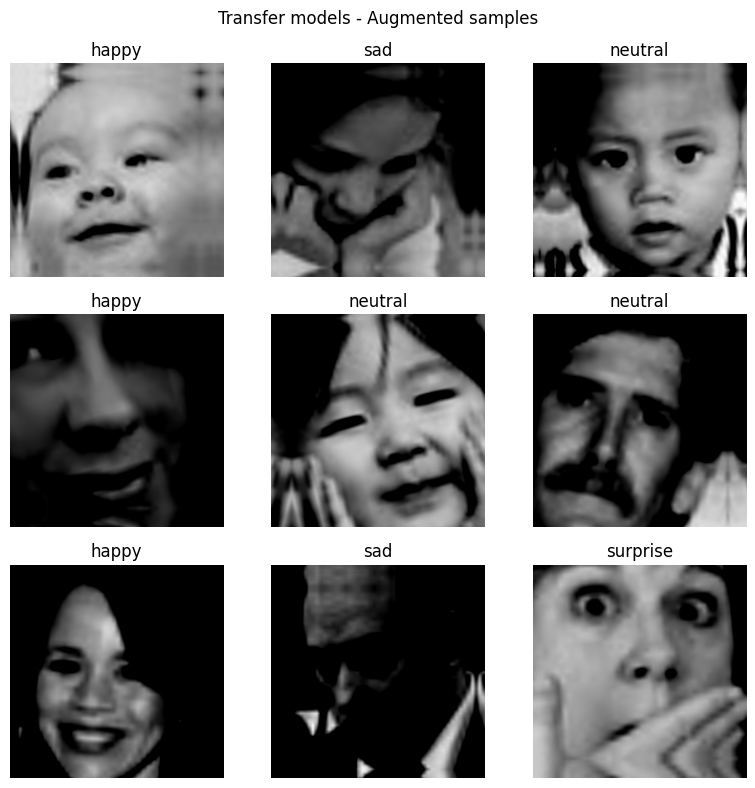

In [ ]:
# Basic augmentation
for images, labels, sample_weights in train_ds_resnet.take(1):
    print('Transfer batch shapes:', images.shape, labels.shape, sample_weights.shape)
    print('Transfer image dtype/min/max:', images.dtype, tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy())
    transfer_sample_images = tf.cast(images, tf.float32).numpy()
    transfer_sample_labels = labels.numpy()
    break

plt.figure(figsize=(8, 8))
for idx in range(min(9, transfer_sample_images.shape[0])):
    plt.subplot(3, 3, idx + 1)
    plt.imshow(transfer_sample_images[idx])
    plt.title(CLASS_NAMES[int(np.argmax(transfer_sample_labels[idx]))])
    plt.axis('off')
plt.suptitle('Transfer models - Augmented samples')
plt.tight_layout()
plt.show()

In [ ]:
val_label_batches = []
for _, labels in val_ds_resnet:
    val_label_batches.append(labels.numpy())
val_true_onehot = np.concatenate(val_label_batches, axis=0)
val_true_labels = np.argmax(val_true_onehot, axis=1)
print('Transfer validation labels stored:', val_true_onehot.shape)

Transfer validation labels stored: (7066, 7)


## Callback Utilities


In [ ]:
# Functions for defining callbacks for the three models
def get_enhanced_callbacks(model_name, timestamp):
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        mode='min',
        verbose=1,
        min_delta=0.001
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_lr=MIN_LR,
        verbose=1,
        min_delta=0.001,
        mode='min'
    )

    checkpoint = ModelCheckpoint(
        filepath=str(MODEL_DIR / f'{model_name}_{timestamp}.h5'),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    tensorboard = TensorBoard(
        log_dir=str(LOG_DIR / f'{model_name}_{timestamp}'),
        histogram_freq=1,
        write_graph=True,
        update_freq='epoch'
    )

    csv_logger = CSVLogger(
        str(LOG_DIR / f'{model_name}_{timestamp}.csv'),
        separator=',',
        append=False
    )

    return [early_stopping, reduce_lr, checkpoint, tensorboard, csv_logger]

## Enhanced CNN Model


In [ ]:
# Function for defining the basic structure of the Enhanced CNN
def create_enhanced_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')
    ])
    return model

In [ ]:
# Compiling the Enhanced CNN
enhanced_cnn_model = create_enhanced_cnn_model()
enhanced_cnn_model._name = 'EnhancedCNN_FER'
print('Enhanced CNN parameters:', enhanced_cnn_model.count_params())

cnn_optimizer = Adam(learning_rate=CNN_LEARNING_RATE)
cnn_precision = tf.keras.metrics.Precision(name='precision')
cnn_recall = tf.keras.metrics.Recall(name='recall')

enhanced_cnn_model.compile(
    optimizer=cnn_optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', cnn_precision, cnn_recall]
)

Enhanced CNN parameters: 1313319


## Transfer Learning Models


In [ ]:
# Function for defining the basic structure of EfficientNet and ResNet
def create_efficientnet_model():
    base_model = keras.applications.EfficientNetV2B0(
        weights='imagenet',
        include_top=False,
        input_shape=TRANSFER_IMAGE_SIZE + (3,)
    )
    base_model.trainable = True
    for layer in base_model.layers[:-25]:
        layer.trainable = False

    inputs = keras.Input(shape=TRANSFER_IMAGE_SIZE + (3,))
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    return keras.Model(inputs, outputs, name='EfficientNetV2B0_FER')


def create_resnet_model():
    base_model = keras.applications.ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=TRANSFER_IMAGE_SIZE + (3,)
    )
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    inputs = keras.Input(shape=TRANSFER_IMAGE_SIZE + (3,))
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_initializer='he_uniform')(x) 
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    return keras.Model(inputs, outputs, name='ResNet50V2_FER')

In [ ]:
# Compiling the transfer learning models
efficientnet_model = create_efficientnet_model()
resnet_model = create_resnet_model()

print('EfficientNet parameters:', efficientnet_model.count_params())
print('ResNet parameters:', resnet_model.count_params())

EfficientNet parameters: 6250071
ResNet parameters: 24619527


In [ ]:
# Compiling the transfer learning models
efficientnet_optimizer = Adam(learning_rate=TRANSFER_LEARNING_RATE)
resnet_optimizer = Adam(learning_rate=1e-5)

eff_precision = tf.keras.metrics.Precision(name='precision')
eff_recall = tf.keras.metrics.Recall(name='recall')
res_precision = tf.keras.metrics.Precision(name='precision')
res_recall = tf.keras.metrics.Recall(name='recall')

efficientnet_model.compile(
    optimizer=efficientnet_optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', eff_precision, eff_recall]
)

resnet_model.compile(
    optimizer=resnet_optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', res_precision, res_recall]
)

transfer_learning_models = [
    (efficientnet_model, 'EfficientNetV2B0_FER'),
    (resnet_model, 'ResNet50V2_FER')
]
print(f'Ready to train {len(transfer_learning_models)} transfer learning models!')

Ready to train 2 transfer learning models!


## Train Enhanced CNN


In [17]:
training_histories = {}

In [ ]:
# Start training Enhanced CNN and little information about images being used
print('' + '=' * 60)
print('TRAINING ENHANCED CNN MODEL')
print('=' * 60)
print(f'  - Input size: {IMG_HEIGHT}x{IMG_WIDTH}x{IMG_CHANNELS}')
print(f'  - Batch size: {CNN_BATCH_SIZE}')
print(f'  - Learning rate: {enhanced_cnn_model.optimizer.learning_rate.numpy():.6f}')
print('  - Mixed precision: enabled')
print('  - Data pipeline: ImageDataGenerator (CPU)')

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
cnn_callbacks = get_enhanced_callbacks('EnhancedCNN_FER', timestamp)

history_cnn = enhanced_cnn_model.fit(
    cnn_train_generator,
    steps_per_epoch=CNN_STEP_SIZE_TRAIN,
    epochs=EPOCHS,
    validation_data=cnn_val_generator,
    validation_steps=CNN_STEP_SIZE_VALID,
    class_weight=class_weights,
    callbacks=cnn_callbacks,
    verbose=1
)

training_histories['EnhancedCNN_FER'] = history_cnn.history
print('Enhanced CNN training complete.')

TRAINING ENHANCED CNN MODEL
  - Input size: 48x48x3
  - Batch size: 128
  - Learning rate: 0.000100
  - Mixed precision: enabled
  - Data pipeline: ImageDataGenerator (CPU)
Epoch 1/150
226/226 [==============================] - ETA: 0s - loss: 3.4830 - accuracy: 0.1597 - precision: 0.1618 - recall: 0.0610
Epoch 1: val_loss improved from inf to 2.07895, saving model to models\EnhancedCNN_FER_20251202_184409.h5
226/226 [==============================] - 30s 108ms/step - loss: 3.4830 - accuracy: 0.1597 - precision: 0.1618 - recall: 0.0610 - val_loss: 2.0789 - val_accuracy: 0.1441 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/150
226/226 [==============================] - ETA: 0s - loss: 3.1659 - accuracy: 0.1755 - precision: 0.1915 - recall: 0.0507
Epoch 2: val_loss improved from 2.07895 to 1.99223, saving model to models\EnhancedCNN_FER_20251202_184409.h5
226/226 [==============================] - 25s 109ms/step - loss: 3.1659 - accuracy: 0.1755 - precisio

## Train Transfer Learning Models


In [ ]:
# Start training the transfer learning models and little information about images being used
for model_idx, (model, model_name) in enumerate(transfer_learning_models, start=1):
    print('' + '=' * 60)
    print(f'TRAINING TRANSFER LEARNING MODEL {model_idx}/{len(transfer_learning_models)}: {model_name}')
    print('=' * 60)
    print(f'  - Input size: {TRANSFER_IMAGE_SIZE}x3')
    print(f'  - Batch size: {TRANSFER_BATCH_SIZE}')
    print(f'  - Learning rate: {model.optimizer.learning_rate.numpy():.6f}')
    print('  - Mixed precision: enabled')
    print('  - Sample weights applied via tf.data pipeline')

    if 'EfficientNet' in model_name:
        train_data = train_ds_eff
        val_data = val_ds_eff
    else:
        train_data = train_ds_resnet
        val_data = val_ds_resnet

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    callbacks = get_enhanced_callbacks(model_name, timestamp)

    history = model.fit(
        train_data,
        steps_per_epoch=TRANSFER_STEP_SIZE_TRAIN,
        epochs=EPOCHS,
        validation_data=val_data,
        validation_steps=TRANSFER_STEP_SIZE_VALID,
        callbacks=callbacks,
        verbose=1
    )

    training_histories[model_name] = history.history
    print(f'Completed training for {model_name}.')


TRAINING TRANSFER LEARNING MODEL 1/2: EfficientNetV2B0_FER
  - Input size: (224, 224)x3
  - Batch size: 64
  - Learning rate: 0.000100
  - Mixed precision: enabled
  - Sample weights applied via tf.data pipeline
Epoch 1/150
451/451 [==============================] - ETA: 0s - loss: 3.1777 - accuracy: 0.2765 - precision: 0.3233 - recall: 0.1784
Epoch 1: val_loss improved from inf to 1.51992, saving model to models\EfficientNetV2B0_FER_20251202_185838.h5
451/451 [==============================] - 57s 113ms/step - loss: 3.1777 - accuracy: 0.2765 - precision: 0.3233 - recall: 0.1784 - val_loss: 1.5199 - val_accuracy: 0.4772 - val_precision: 0.6894 - val_recall: 0.2663 - lr: 1.0000e-04
Epoch 2/150
451/451 [==============================] - ETA: 0s - loss: 2.6117 - accuracy: 0.3764 - precision: 0.4614 - recall: 0.2592
Epoch 2: val_loss improved from 1.51992 to 1.39820, saving model to models\EfficientNetV2B0_FER_20251202_185838.h5
451/451 [==============================] - 51s 110ms/step - l

## Evaluation


EVALUATING EnhancedCNN_FER
56/56 [==============================] - 2s 44ms/step - loss: 1.4284 - accuracy: 0.4707 - precision: 0.6613 - recall: 0.2927
Validation metrics: {'loss': 1.4283958673477173, 'accuracy': 0.4707047939300537, 'precision': 0.6613367199897766, 'recall': 0.2926691174507141}
              precision    recall  f1-score   support

       angry     0.3144    0.4896    0.3829       960
     disgust     0.1180    0.6306    0.1989       111
        fear     0.3324    0.1169    0.1730      1018
       happy     0.7683    0.6614    0.7108      1825
     neutral     0.4421    0.5493    0.4899      1216
         sad     0.4419    0.1703    0.2459      1139
    surprise     0.5441    0.7503    0.6308       797

    accuracy                         0.4707      7066
   macro avg     0.4230    0.4812    0.4046      7066
weighted avg     0.4996    0.4707    0.4588      7066



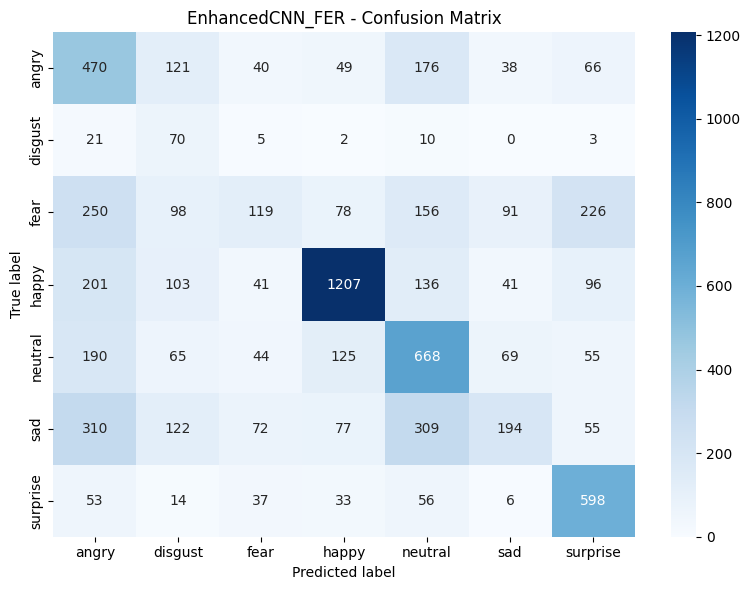

EVALUATING EfficientNetV2B0_FER
111/111 [==============================] - 5s 44ms/step - loss: 1.0418 - accuracy: 0.6816 - precision: 0.7820 - recall: 0.5743
Validation metrics: {'loss': 1.0418274402618408, 'accuracy': 0.681573748588562, 'precision': 0.7820389270782471, 'recall': 0.5742994546890259}
              precision    recall  f1-score   support

       angry     0.5796    0.6333    0.6053       960
     disgust     0.6972    0.6847    0.6909       111
        fear     0.5754    0.4872    0.5277      1018
       happy     0.8900    0.8559    0.8726      1825
     neutral     0.5891    0.7015    0.6404      1216
         sad     0.5802    0.5206    0.5488      1139
    surprise     0.7649    0.7880    0.7763       797

    accuracy                         0.6816      7066
   macro avg     0.6681    0.6673    0.6660      7066
weighted avg     0.6837    0.6816    0.6807      7066



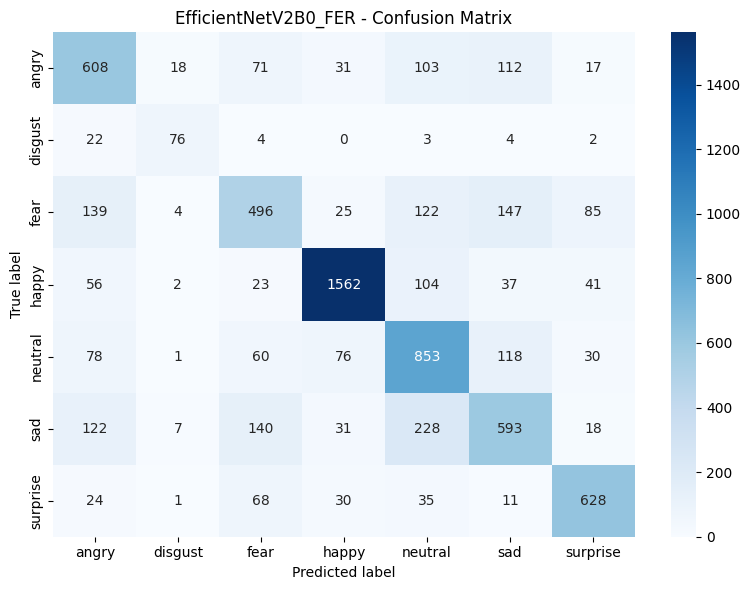

EVALUATING ResNet50V2_FER
111/111 [==============================] - 5s 44ms/step - loss: 1.1393 - accuracy: 0.6451 - precision: 0.7457 - recall: 0.5330
Validation metrics: {'loss': 1.1392884254455566, 'accuracy': 0.6450608372688293, 'precision': 0.7457425594329834, 'recall': 0.5329747796058655}
              precision    recall  f1-score   support

       angry     0.5212    0.6010    0.5583       960
     disgust     0.5630    0.6036    0.5826       111
        fear     0.4939    0.4381    0.4643      1018
       happy     0.8964    0.8247    0.8590      1825
     neutral     0.5715    0.6505    0.6085      1216
         sad     0.5273    0.4996    0.5131      1139
    surprise     0.7585    0.7566    0.7575       797

    accuracy                         0.6451      7066
   macro avg     0.6188    0.6249    0.6205      7066
weighted avg     0.6512    0.6451    0.6466      7066



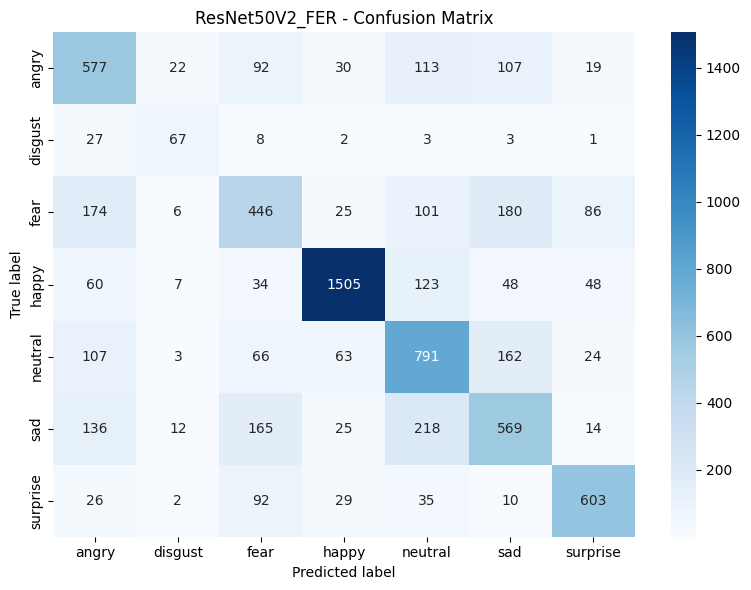

In [ ]:
# Evaluating all 3 models- Enhanced CNN, EfficientNet and ResNet
def evaluate_model(model, model_name, dataset, val_labels, steps):
    print('' + '=' * 60)
    print(f'EVALUATING {model_name}')
    print('=' * 60)
    eval_results = model.evaluate(dataset, steps=steps, verbose=1)
    metric_dict = dict(zip(model.metrics_names, eval_results))
    print('Validation metrics:', metric_dict)

    preds = model.predict(dataset, steps=steps, verbose=0)
    preds = preds[:len(val_labels)]
    y_pred = np.argmax(preds, axis=1)

    report = classification_report(val_labels, y_pred, target_names=CLASS_NAMES, digits=4)
    print(report)

    cm = confusion_matrix(val_labels, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    return preds

cnn_val_preds = evaluate_model(enhanced_cnn_model, 'EnhancedCNN_FER', cnn_val_generator, cnn_val_true_labels, CNN_STEP_SIZE_VALID)
efficientnet_val_preds = evaluate_model(efficientnet_model, 'EfficientNetV2B0_FER', val_ds_eff, val_true_labels, TRANSFER_STEP_SIZE_VALID)
resnet_val_preds = evaluate_model(resnet_model, 'ResNet50V2_FER', val_ds_resnet, val_true_labels, TRANSFER_STEP_SIZE_VALID)

## Ensemble (Transfer Models)


Ensemble accuracy: 0.6920
              precision    recall  f1-score   support

       angry     0.5873    0.6479    0.6161       960
     disgust     0.7477    0.7207    0.7339       111
        fear     0.5771    0.4892    0.5295      1018
       happy     0.8986    0.8641    0.8810      1825
     neutral     0.6037    0.7155    0.6549      1216
         sad     0.5909    0.5364    0.5624      1139
    surprise     0.7831    0.7930    0.7880       797

    accuracy                         0.6920      7066
   macro avg     0.6841    0.6810    0.6808      7066
weighted avg     0.6942    0.6920    0.6913      7066



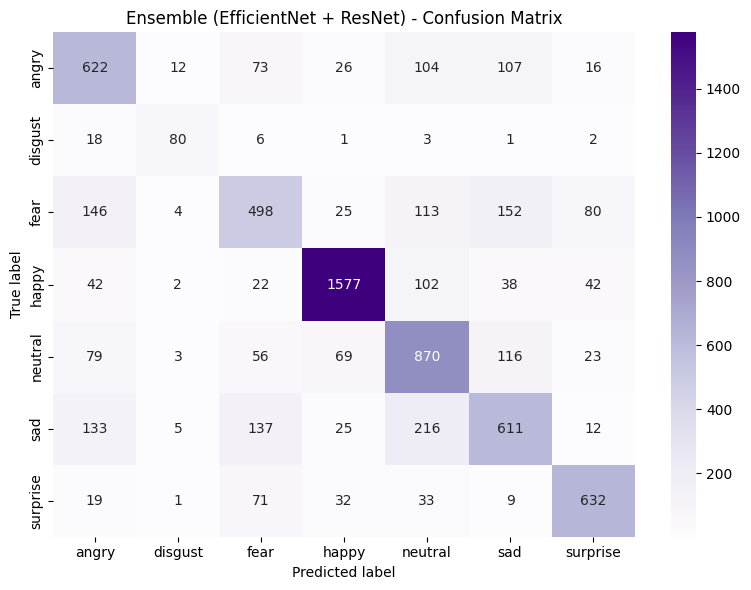

In [ ]:
# Creating an ensemble for transfer learning models
ensemble_probs = np.mean([efficientnet_val_preds, resnet_val_preds], axis=0)
ensemble_probs = ensemble_probs[:len(val_true_labels)]
ensemble_classes = np.argmax(ensemble_probs, axis=1)
ensemble_accuracy = accuracy_score(val_true_labels, ensemble_classes)
print(f'Ensemble accuracy: {ensemble_accuracy:.4f}')
print(classification_report(val_true_labels, ensemble_classes, target_names=CLASS_NAMES, digits=4))

ensemble_cm = confusion_matrix(val_true_labels, ensemble_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(ensemble_cm, annot=True, fmt='d', cmap='Purples', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Ensemble (EfficientNet + ResNet) - Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

## Save Configuration Snapshot


In [22]:
"""
config_snapshot = {
    'models_trained': ['EnhancedCNN_FER'] + [name for _, name in transfer_learning_models],
    'class_names': CLASS_NAMES,
    'cnn_batch_size': CNN_BATCH_SIZE,
    'transfer_batch_size': TRANSFER_BATCH_SIZE,
    'cnn_image_size': (IMG_HEIGHT, IMG_WIDTH),
    'transfer_image_size': TRANSFER_IMAGE_SIZE,
    'epochs': EPOCHS,
    'cnn_learning_rate': CNN_LEARNING_RATE,
    'transfer_learning_rate': TRANSFER_LEARNING_RATE,
    'class_weights': class_weights,
    'pipelines': {
        'cnn': {
            'shuffle': True,
            'augmentations': ['RandomFlip', 'RandomRotation(0.0417)', 'RandomTranslation(0.15,0.15)', 'RandomZoom(0.15)'],
            'normalization': 'images / 255.0',
            'sample_weight_source': 'CLASS_WEIGHT_VECTOR + tf.argmax(labels)'
        },
        'transfer': {
            'shuffle': True,
            'augmentations': ['RandomFlip', 'RandomRotation(0.0417)', 'RandomTranslation(0.15,0.15)', 'RandomZoom(0.15)'],
            'normalization': 'images / 255.0',
            'sample_weight_source': 'CLASS_WEIGHT_VECTOR + tf.argmax(labels)'
        }
    }
}

config_path = MODEL_DIR / 'enhanced_tfdata_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config_snapshot, f, indent=4)
print(f'Configuration snapshot saved to: {config_path}')
"""

"\nconfig_snapshot = {\n    'models_trained': ['EnhancedCNN_FER'] + [name for _, name in transfer_learning_models],\n    'class_names': CLASS_NAMES,\n    'cnn_batch_size': CNN_BATCH_SIZE,\n    'transfer_batch_size': TRANSFER_BATCH_SIZE,\n    'cnn_image_size': (IMG_HEIGHT, IMG_WIDTH),\n    'transfer_image_size': TRANSFER_IMAGE_SIZE,\n    'epochs': EPOCHS,\n    'cnn_learning_rate': CNN_LEARNING_RATE,\n    'transfer_learning_rate': TRANSFER_LEARNING_RATE,\n    'class_weights': class_weights,\n    'pipelines': {\n        'cnn': {\n            'shuffle': True,\n            'augmentations': ['RandomFlip', 'RandomRotation(0.0417)', 'RandomTranslation(0.15,0.15)', 'RandomZoom(0.15)'],\n            'normalization': 'images / 255.0',\n            'sample_weight_source': 'CLASS_WEIGHT_VECTOR + tf.argmax(labels)'\n        },\n        'transfer': {\n            'shuffle': True,\n            'augmentations': ['RandomFlip', 'RandomRotation(0.0417)', 'RandomTranslation(0.15,0.15)', 'RandomZoom(0.15)']

In [ ]:
# Select best model by validation accuracy and save as best_model.h5
model_eval_specs = [
    (enhanced_cnn_model, 'EnhancedCNN_FER', cnn_val_generator, CNN_STEP_SIZE_VALID),
    (efficientnet_model, 'EfficientNetV2B0_FER', val_ds_eff, TRANSFER_STEP_SIZE_VALID),
    (resnet_model, 'ResNet50V2_FER', val_ds_resnet, TRANSFER_STEP_SIZE_VALID),
]

best_model = None
best_name = None
best_acc = -1.0
best_metrics = None

for model, name, dataset, steps in model_eval_specs:
    results = model.evaluate(dataset, steps=steps, verbose=0)
    metrics = dict(zip(model.metrics_names, results))
    acc = metrics.get('accuracy', metrics.get('acc', 0.0))
    print(f"{name} val accuracy: {acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name
        best_metrics = metrics

best_model_path = MODEL_DIR / 'best_model.h5'
best_model.save(best_model_path, include_optimizer=False)
print(f"Best model: {best_name} (val acc {best_acc:.4f}) saved to {best_model_path}")

EnhancedCNN_FER val accuracy: 0.4707
EfficientNetV2B0_FER val accuracy: 0.6816
ResNet50V2_FER val accuracy: 0.6451
Best model: EfficientNetV2B0_FER (val acc 0.6816) saved to models\best_model.h5


# Why we didn't use Ensemble of ResNet and EfficientNet for our best model selection process?
a) The ensemble only gave a small lift (~1% accuracy / ~1–1.5% macro recall), so the improvement isn’t large enough to justify the added complexity.

b) Real‑time use prioritizes speed and simplicity; a single EfficientNet runs faster and is easier to deploy, debug, and maintain.

c) Two‑model inference doubles compute and memory, which hurts latency and user experience on webcam feeds.

Conclusion: - An ensemble means we run two full models per frame (EfficientNet + ResNet) and then average outputs. That roughly doubles inference time and memory, so webcam detection/prediction becomes slower and less responsive.

In [ ]:
# Quick sanity check on best_model.h5 using a random validation image
import random
from tensorflow.keras.preprocessing import image as keras_image

# gather all validation images
val_image_paths = []
for cls in CLASS_NAMES:
    cls_dir = VAL_DIR / cls
    val_image_paths.extend(list(cls_dir.glob('*.jpg')))
    val_image_paths.extend(list(cls_dir.glob('*.jpeg')))
    val_image_paths.extend(list(cls_dir.glob('*.png')))

if not val_image_paths:
    print("No validation images found to test.")
else:
    sample_path = random.choice(val_image_paths)
    print(f"Testing image: {sample_path}")

    # Load best_model.h5 to mirror realtime usage
    try:
        best_model = tf.keras.models.load_model(MODEL_DIR / 'best_model.h5', compile=False)
        print(f"Loaded best model: {best_model.name}, input_shape: {best_model.input_shape}")
    except Exception as e:
        print("Error loading best_model.h5, falling back to efficientnet_model:", e)
        best_model = efficientnet_model

    target_h, target_w = best_model.input_shape[1], best_model.input_shape[2]
    img = keras_image.load_img(sample_path, target_size=(target_h, target_w))
    arr = keras_image.img_to_array(img)

    model_name = getattr(best_model, 'name', '').lower()
    if target_h <= 64:
        arr = arr / 255.0
    elif 'resnet' in model_name:
        arr = resnet_preprocess(arr)
    else:
        arr = eff_preprocess(arr)

    preds = best_model.predict(np.expand_dims(arr, axis=0), verbose=0)[0]
    top_idx = int(np.argmax(preds))
    top3 = sorted(zip(CLASS_NAMES, preds), key=lambda x: x[1], reverse=True)[:3]
    print(f"Predicted: {CLASS_NAMES[top_idx]} (prob {preds[top_idx]:.3f})")
    print("Top-3:")
    for lbl, p in top3:
        print(f"  {lbl}: {p:.3f}")

Testing image: data\images\images\validation\happy\20595.jpg
Loaded best model: EfficientNetV2B0_FER, input_shape: (None, 224, 224, 3)
Predicted: happy (prob 0.948)
Top-3:
  happy: 0.948
  fear: 0.014
  surprise: 0.014


## Conclusion & Stakeholder Insights

**Summary of work completed**
- Built three FER models: Enhanced CNN (48x48), EfficientNetV2B0 (transfer, 224x224), and ResNet50V2 (transfer, 224x224).
- Applied balanced training (class weights), strong data augmentation, and early-stopping/learning-rate scheduling.
- Evaluated each model with full metrics and confusion matrices; compared against an EfficientNet+ResNet ensemble.
- Implemented a real-time inference pipeline with correct preprocessing and improved face-crop handling.
- Added a lightweight Streamlit dashboard for webcam/upload demos.

**Key results & insights**
- EfficientNetV2B0 delivers the best single model validation performance and is the preferred choice for deployment.
- The ensemble offers a small accuracy/recall lift but increases latency and complexity; not worth it for real-time use.
- Misclassifications cluster around harder emotions (disgust/fear/surprise), often due to subtle facial cues and crop quality.
- Correct preprocessing (EfficientNet/ResNet `preprocess_input`) is critical; plain /255 scaling degrades transfer models.

**Stakeholder guidance**
- **Deploy EfficientNetV2B0** for the best balance of accuracy and real-time speed.
- **Prioritize reliable face crops** (Haar/face-specific detectors) to stabilize predictions in live settings.
- **Use confidence thresholds + smoothing** to reduce flicker in UI; adjust for rare classes as needed.
- **Monitor bias and drift**: track per-class performance in production, especially for disgust/fear/surprise.

**Next steps (if time permits)**
- Collect more samples for under-represented emotions to improve recall.
- Test a face-specific detector (e.g., Mediapipe/YOLO-face) for more stable runtime crops.
- Package the best model as a float32-compatible export to avoid H5 load issues in some environments.
